# Lecture 5: Introduction to Deep Learning

## Import useful libraries

In [1]:
!pip install torch

In [2]:
# ========= Import Useful Libraries ========= #
import torch
from torch import nn
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import tqdm
import matplotlib.pyplot as plt


## Define hyperparameters
In machine learning, hyperparameters are configuration values set before training a model.
They are not learned from the data; instead, they control how the learning process happens.
Choosing good hyperparameters is crucial because they influence training stability, speed, and overall performance.

### RANDOM_SEED
Sets the seed for all random operations (data shuffling, weight initialization).
A fixed seed ensures reproducibility, meaning that repeating the training yields consistent results.

### LEARNING_RATE
Determines the step size used during gradient descent.
Too high: unstable training;
too low: slow learning.

### BATCH_SIZE
Number of samples processed before updating the model’s weights.
- Larger batch sizes leads to more stable and smoother gradient estimates (due to averaging over more samples), but also higher memory usage.

- Smaller batch sizes imply nnoisier gradients and lower memory consumption, but training may be less stable.

### OPTIMIZER
The optimizer is the algorithm used to update the model’s weights during training based on the computed gradients.
Its role is to efficiently navigate the loss landscape and find parameter values that minimize the loss function.

### LOSS FUNCTION
The loss function measures how well the model’s predictions match the true labels.

The choice of the loss function depends on the task:

REGRESSION:

Mean Squared Error (MSE) is the most common choice.


---

BINARY CLASSIFICATIONN:

Binary Cross-Entropy (BCE) compares the true label (0 or 1) to the predicted probability.

---

MULTI-CLASS CLASSIFICATION

Categorical Cross-Entropy (CE) evaluates how much probability the model assigns to the correct class.

---

There are many other loss functions as well.
Some are designed to handle class imbalance (e.g., Weighted Cross-Entropy, Focal Loss), while others are tailored for specific applications such as segmentation, ranking, or metric learning.

It is also possible to implement custom loss functions to better exploit the properties of the specific domain or dataset being used.
In practice, choosing the right loss function is a key part of designing an effective model.

In [3]:
# parameters
RANDOM_SEED = 42
LEARNING_RATE = 0.001
BATCH_SIZE = 64
N_EPOCHS = 15
loss_fn = nn.CrossEntropyLoss()

IMG_SIZE = 28
N_CLASSES = 10

## Define dataset and dataset transforms
The MNIST dataset is a classic benchmark in machine learning used to test models. It consists of 70,000 grayscale images of handwritten digits from 0 to 9. Each image is labeled with the digit it represents.
Each image is 28×28 pixels and contains a single centered digit written by different people

In [4]:
# define transformations to apply to the dataset
# the dataset must be transformed into a Tensor
transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                transforms.ToTensor()])
train_dataset = MNIST('./data', train=True, download=True, transform = transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.06MB/s]


In [5]:
print(f"size of train dataset: {len(train_dataset)}")

size of train dataset: 60000


### Plotting images

In [6]:
ROW_IMG = 10
N_ROWS = 5

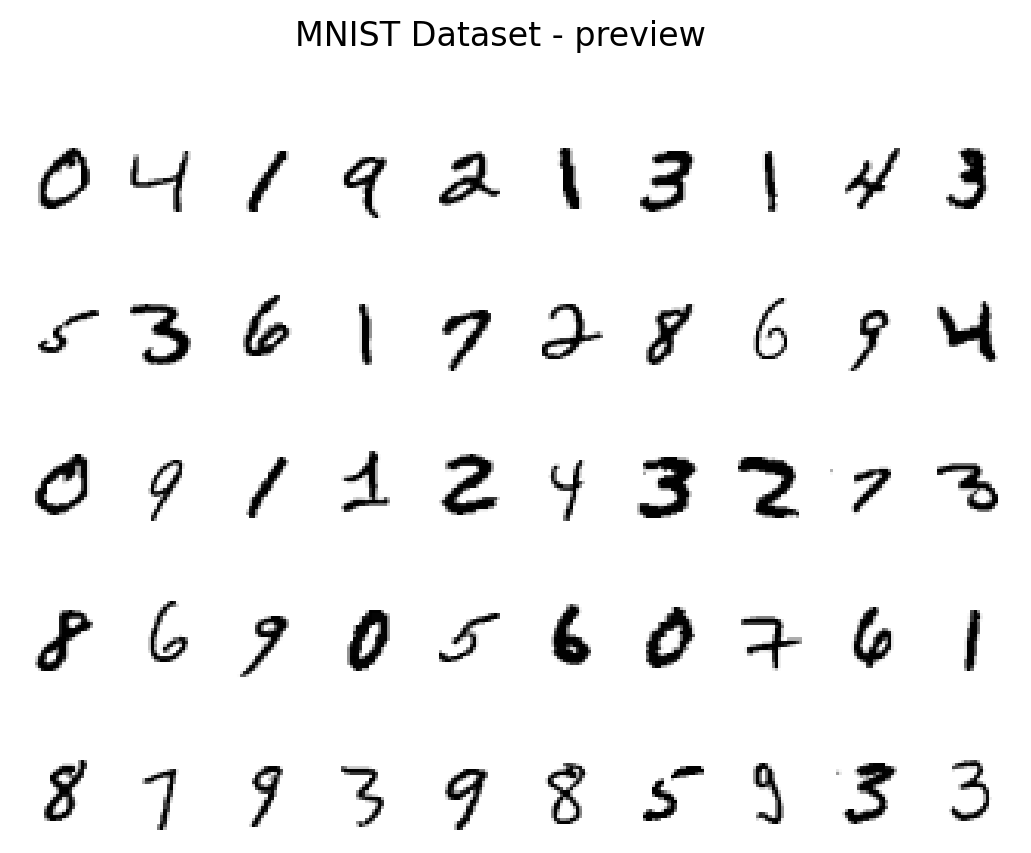

In [7]:
%config InlineBackend.figure_format = 'retina'
fig = plt.figure()
for index in range(1, ROW_IMG * N_ROWS + 1):
    plt.subplot(N_ROWS, ROW_IMG, index)
    plt.axis('off')
    plt.imshow(train_dataset.data[index], cmap = 'gray_r')
fig.suptitle('MNIST Dataset - preview');

## Neural Network architecture


The model defined below is a fully connected (feed-forward) neural network, also known as a Multilayer Perceptron (MLP).
It is composed exclusively of Linear (dense) layers, meaning that every neuron in one layer is connected to every neuron in the next layer.

---
The architecture consists of:

- An input layer that receives flattened 28x28 images (784 features).

- Two hidden layers, each with 200 neurons, both followed by a ReLU activation function.

- An output layer with 10 units, corresponding to the 10 classes of the classification task.

---
The forward pass applies: a linear transformation, a non-linear activation (ReLU), another linear activation block, a final linear layer and ReLU.


Although this model works, it is not the ideal architecture for image data.
MLPs do not exploit the spatial structure of images because they treat the input as a long 1-dimensional vector, ignoring:

- local patterns,

- spatial relationships between pixels,

- translation invariance.

For image tasks, Convolutional Neural Networks (CNNs) are generally preferred.

In [30]:
# ========= Define Models ========= #
# Define the Neural Network
class NeuralNetwork(nn.Module):
    def __init__(self):
      super().__init__()
      self.layer1 = nn.Linear(in_features = IMG_SIZE*IMG_SIZE, out_features = 200)
      self.layer2 = nn.Linear(in_features = 200, out_features = 200)
      self.layer3 = nn.Linear(in_features = 200, out_features =  N_CLASSES)
      self.activation = nn.ReLU()

    def forward(self, x):
      vz = self.layer1(x)
      z = self.activation(vz)
      vf = self.layer2(z)
      f = self.activation(vf)
      vy = self.layer3(f)
      y = self.activation(vy)

      return y


## Initialize training

In [31]:
torch.manual_seed(RANDOM_SEED) # setting seed for reproducibility
# define model hyperparameters
model = NeuralNetwork()
size = len(train_dataset)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


In [11]:
# Lists to store training metrics
train_losses = []
train_accuracies = []

In [12]:
%%time
for epoch in range(N_EPOCHS):
    print(f"Epoch {epoch+1}\n-------------------------------")

    # ----- TRAINING PHASE -----
    model.train()
    epoch_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X.view(X.shape[0], -1))
        loss = loss_fn(y_pred, y)

        # Backward pass + update weights
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Track loss and accuracy
        epoch_train_loss += loss.item()
        _, predicted = torch.max(y_pred.data, 1)
        correct_train += (predicted == y).sum().item()
        total_train += y.size(0)


    print(f"loss: {loss.item():>7f}")

    # Average training loss and accuracy for this epoch
    epoch_train_loss /= len(train_loader)
    epoch_train_acc = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # Print metrics for this epoch
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")

Epoch 1
-------------------------------
loss: 2.285503
Train Loss: 2.2933 | Train Acc: 0.1817
Epoch 2
-------------------------------
loss: 2.266785
Train Loss: 2.2701 | Train Acc: 0.3602
Epoch 3
-------------------------------
loss: 2.250538
Train Loss: 2.2347 | Train Acc: 0.4744
Epoch 4
-------------------------------
loss: 2.124464
Train Loss: 2.1798 | Train Acc: 0.5126
Epoch 5
-------------------------------
loss: 1.985479
Train Loss: 2.0923 | Train Acc: 0.5200
Epoch 6
-------------------------------
loss: 1.798784
Train Loss: 1.9641 | Train Acc: 0.5262
Epoch 7
-------------------------------
loss: 1.742582
Train Loss: 1.8088 | Train Acc: 0.5304
Epoch 8
-------------------------------
loss: 1.688272
Train Loss: 1.6603 | Train Acc: 0.5419
Epoch 9
-------------------------------
loss: 1.726005
Train Loss: 1.5423 | Train Acc: 0.5613
Epoch 10
-------------------------------
loss: 1.399430
Train Loss: 1.4541 | Train Acc: 0.5802
Epoch 11
-------------------------------
loss: 1.504822
Tra

## Visualize trends during training

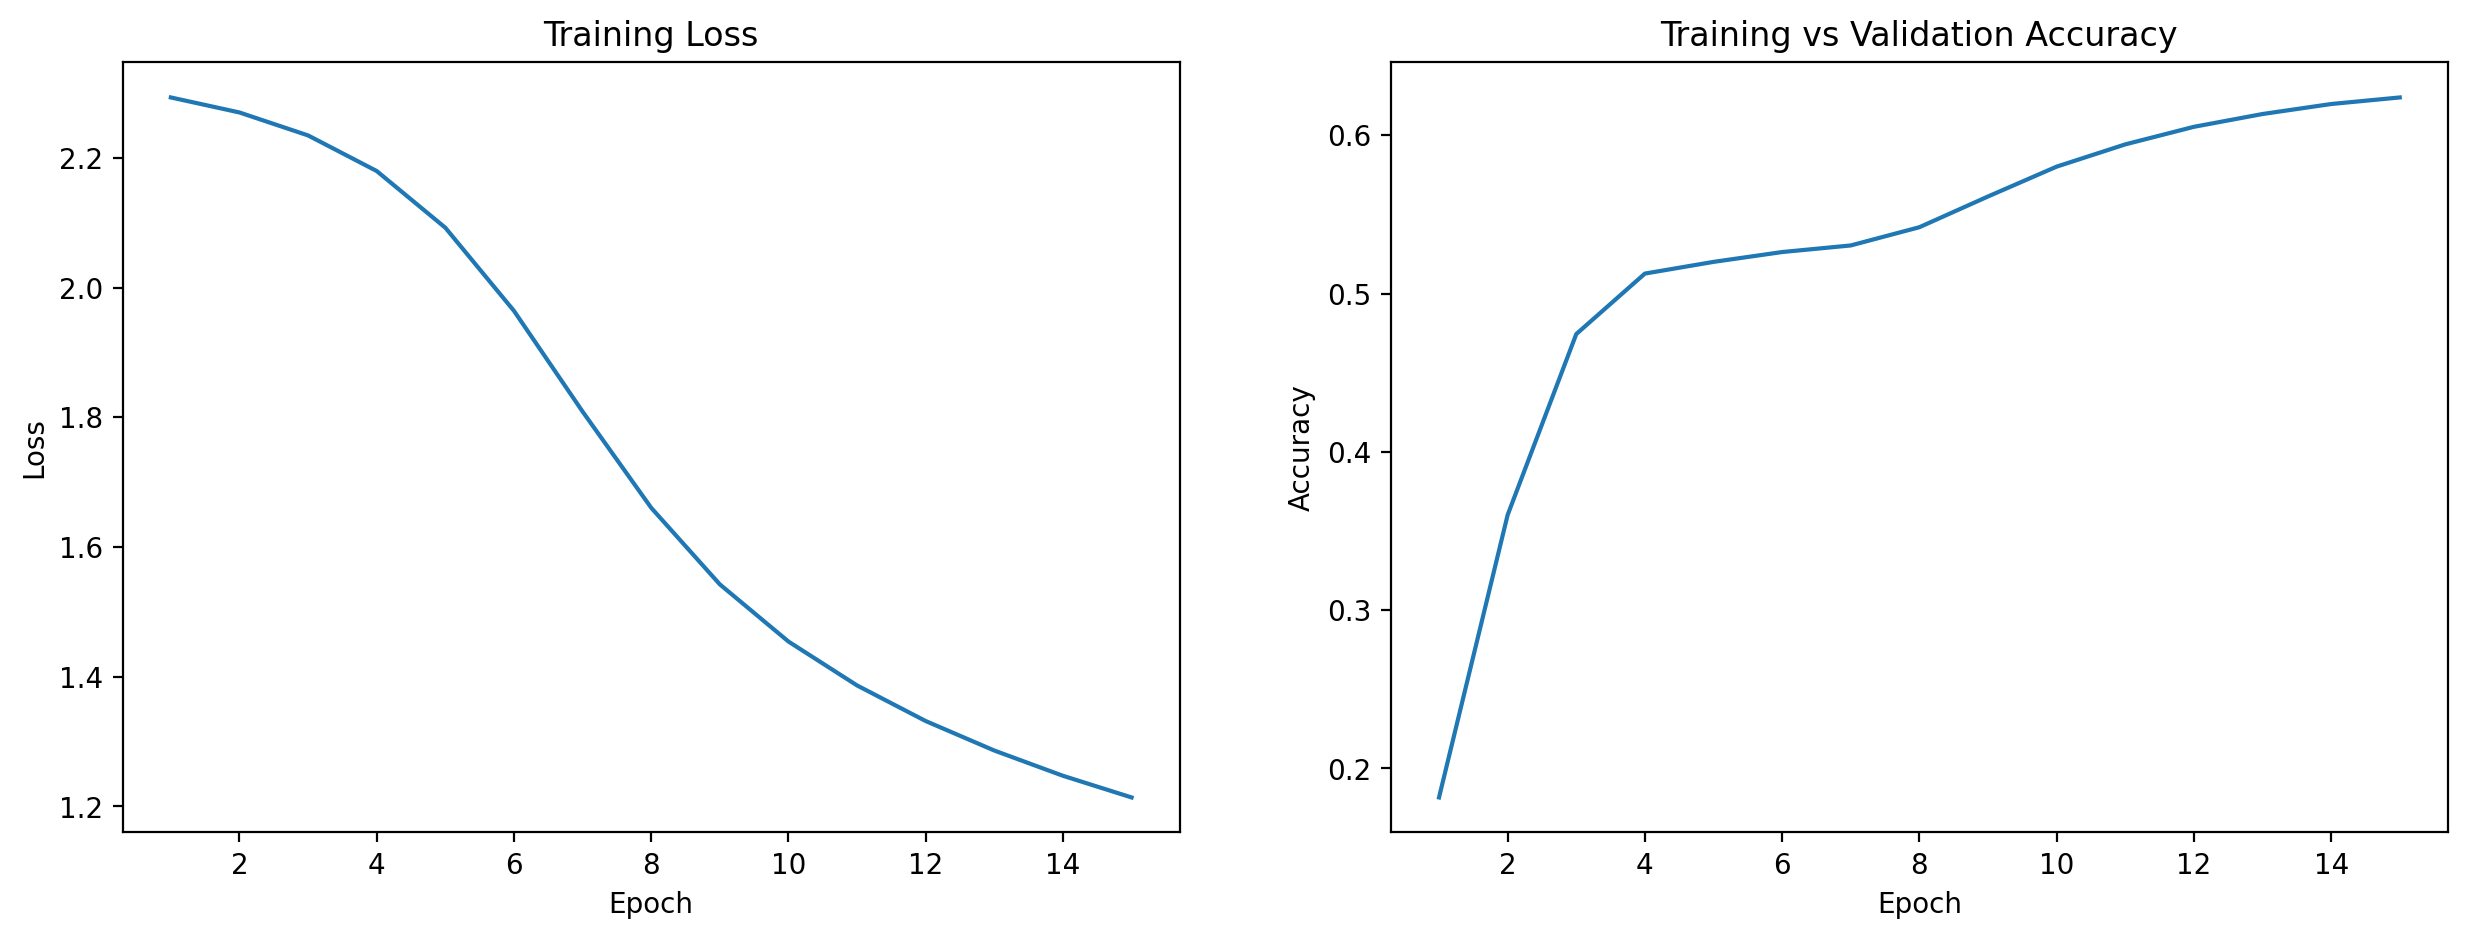

In [16]:
epochs = range(1, N_EPOCHS + 1)


plt.figure(figsize=(15, 5))
# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()



## Convolutional Neural Networks

In [32]:


class ConvNeuralNetwork(nn.Module):
    def __init__(self):
        super(ConvNeuralNetwork, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 20, kernel_size=4, stride=1)
        self.conv2 = nn.Conv2d(in_channels = 20, out_channels = 20, kernel_size=5, stride=2)
        self.maxpool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.flatten = nn.Flatten()
        self.activation = nn.ReLU()

        self.batchnorm_1 = nn.BatchNorm2d(num_features = 20)
        self.batchnorm_2 = nn.BatchNorm2d(num_features = 20)

        self.linear1 = nn.Linear(in_features = 20 * 5 * 5, out_features = 250)
        self.linear2 = nn.Linear(in_features = 250, out_features = N_CLASSES)
        self.batchnorm_fc = nn.BatchNorm1d(num_features = 250) # batch norm of the fully connected layer, so we go back at 1D dimension

    def forward(self, x):
        x = self.activation(self.batchnorm_1(self.conv1(x)))  # (20, 25, 25)
        x = self.activation(self.batchnorm_2(self.conv2(x)))  # (20, 11, 11)
        x = self.maxpool(x)  # (20, 5, 5)
        x = self.flatten(x)  # (20 * 5 * 5)
        x = self.batchnorm_fc(self.linear1(x))  # (250, )
        x = self.activation(x)

        # Final linear layer
        x = self.linear2(x)  # (10, )
        return x

In [29]:
model = ConvNeuralNetwork()
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

In [21]:
# Lists to store training metrics
train_losses = []
train_accuracies = []


In [22]:
%%time
for epoch in range(N_EPOCHS):
    print(f"Epoch {epoch+1}\n-------------------------------")

    # ----- TRAINING PHASE -----
    model.train()
    epoch_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        # Backward pass + update weights
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Track loss and accuracy
        epoch_train_loss += loss.item()
        _, predicted = torch.max(y_pred.data, 1)
        correct_train += (predicted == y).sum().item()
        total_train += y.size(0)


    print(f"loss: {loss.item():>7f}")

    # Average training loss and accuracy for this epoch
    epoch_train_loss /= len(train_loader)
    epoch_train_acc = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # Print metrics for this epoch
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")


Epoch 1
-------------------------------
loss: 0.503195
Train Loss: 1.0995 | Train Acc: 0.7579
Epoch 2
-------------------------------
loss: 0.326664
Train Loss: 0.4630 | Train Acc: 0.9164
Epoch 3
-------------------------------
loss: 0.258719
Train Loss: 0.3126 | Train Acc: 0.9393
Epoch 4
-------------------------------
loss: 0.234543
Train Loss: 0.2440 | Train Acc: 0.9498
Epoch 5
-------------------------------
loss: 0.354396
Train Loss: 0.2058 | Train Acc: 0.9553
Epoch 6
-------------------------------
loss: 0.354426
Train Loss: 0.1794 | Train Acc: 0.9604
Epoch 7
-------------------------------
loss: 0.095687
Train Loss: 0.1599 | Train Acc: 0.9639
Epoch 8
-------------------------------
loss: 0.120021
Train Loss: 0.1459 | Train Acc: 0.9659
Epoch 9
-------------------------------
loss: 0.151909
Train Loss: 0.1352 | Train Acc: 0.9676
Epoch 10
-------------------------------
loss: 0.238760
Train Loss: 0.1249 | Train Acc: 0.9702
Epoch 11
-------------------------------
loss: 0.074352
Tra

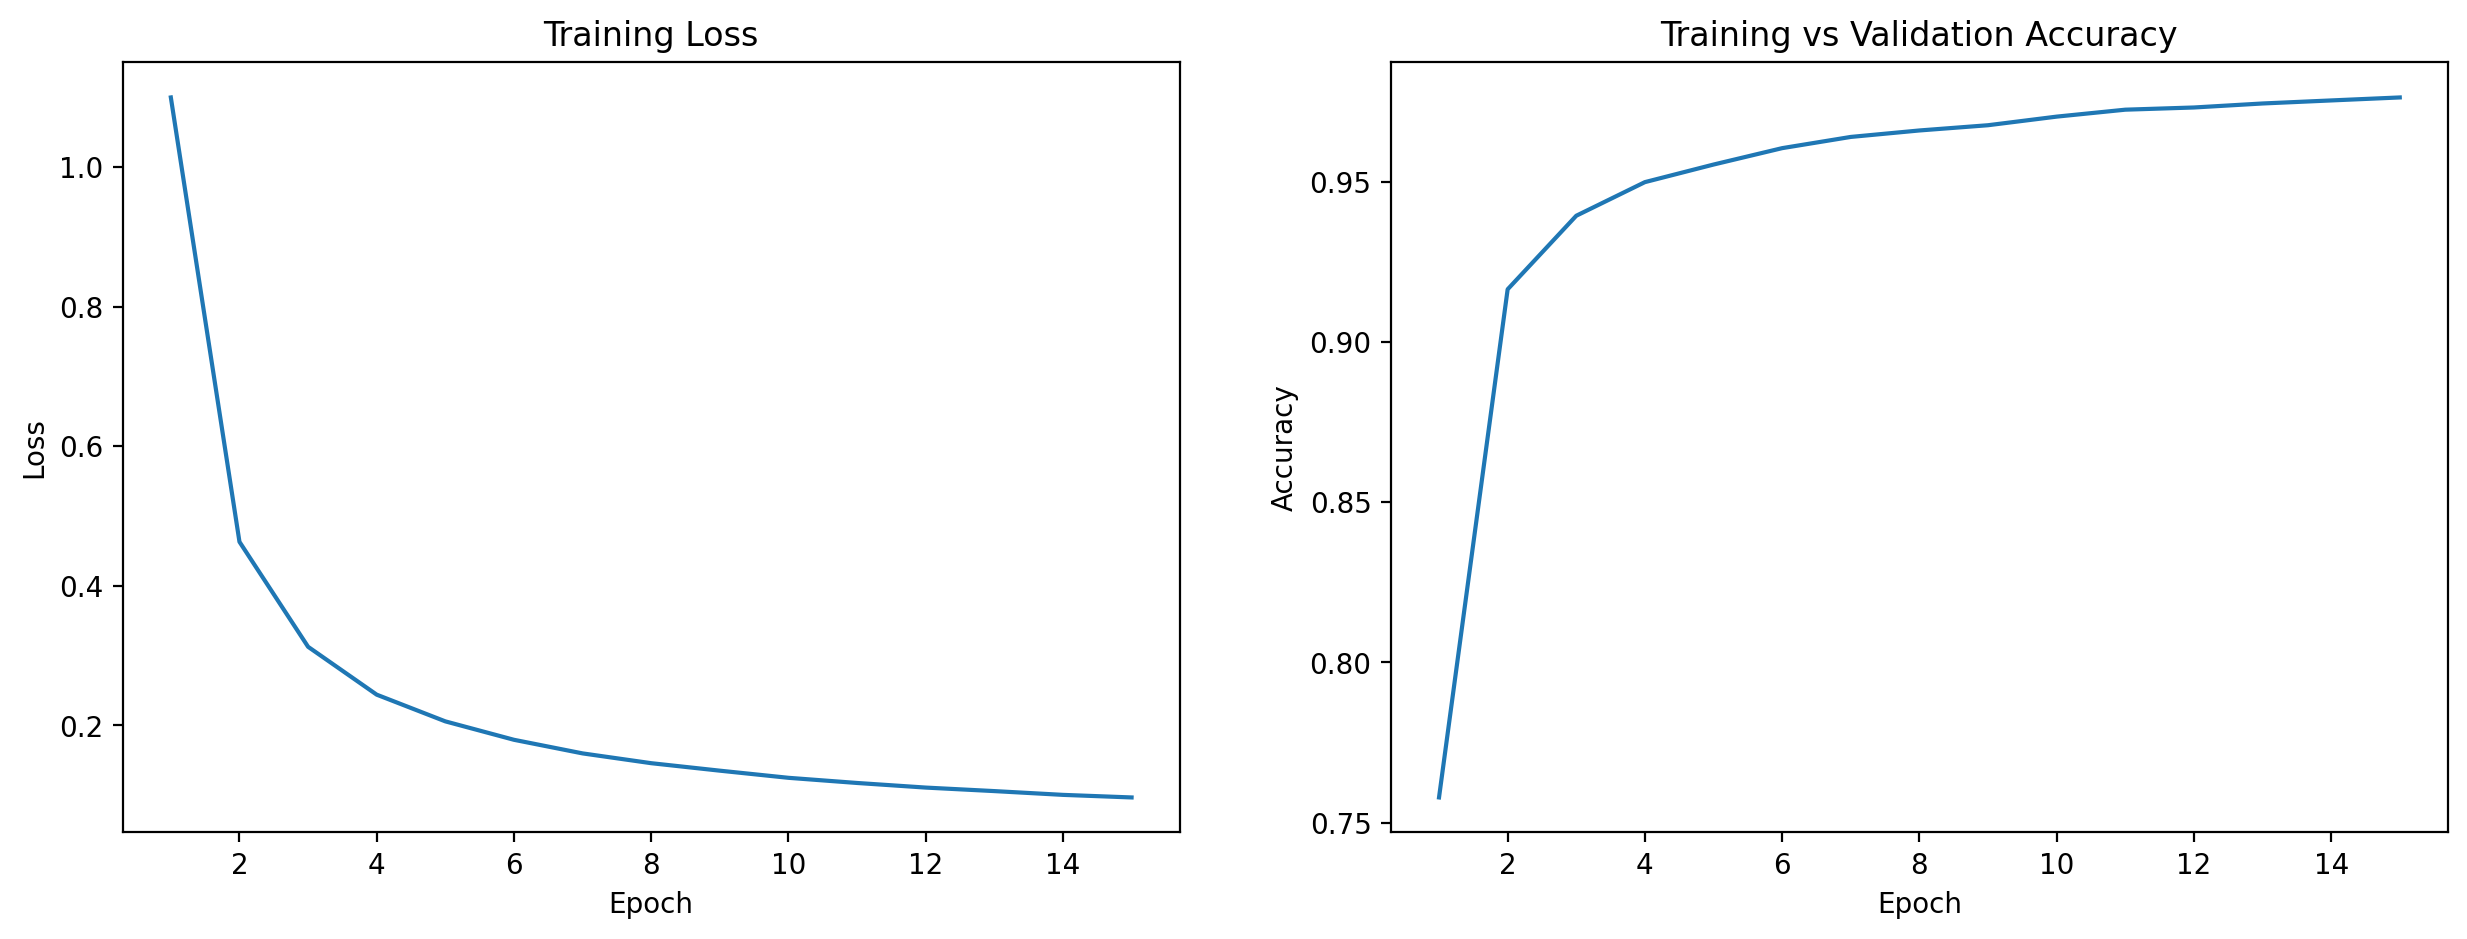

In [23]:
epochs = range(1, N_EPOCHS + 1)


plt.figure(figsize=(15, 5))
# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()